<a href="https://colab.research.google.com/github/semihaberra/olasilik-projesi/blob/main/ev_fiyat_analizi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Veriyi okutuyoruz
df = pd.read_csv('istanbul_apartment_prices_2026.csv')

# Verinin ilk 5 satırını ekrana yazdırıyoruz ki doğru gelmiş mi görelim
df.head()

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04


In [2]:
# Her sütundaki eksik veri yüzdesini hesaplayalım
eksik_oranlari = (df.isnull().sum() / len(df)) * 100

# Sadece eksik veri olanları, en çoktan en aza doğru sıralayıp görelim
print("Sütunlardaki Eksik Veri Yüzdeleri:")
print(eksik_oranlari[eksik_oranlari > 0].sort_values(ascending=False))

Sütunlardaki Eksik Veri Yüzdeleri:
complex_name          84.846772
floor_category        70.141721
maintenance_fee       63.653248
building_type         58.791941
fuel_type             55.933298
building_condition    55.909073
last_updated          48.019542
orientation           21.464045
floor                  7.740138
exchange               6.448096
furnished              4.352566
usage_status           2.559858
bathroom_count         0.948843
credit_eligible        0.028263
total_floors           0.004038
deed_status            0.004038
dtype: float64


In [3]:
# Dokümanda istenen gereksiz sütunları bir listede topluyoruz
silinecek_sutunlar = ['complex_name', 'floor_category', 'last_updated', 'scraped_at', 'listing_id']

# Bu sütunları tablodan çıkarıp 'df_temiz' adında yeni bir tablo oluşturuyoruz
# Artık orijinal 'df' yerine hep bu 'df_temiz' üzerinden gideceğiz.
df_temiz = df.drop(columns=silinecek_sutunlar)

# Tablomuzun son halinde kaç satır ve sütun kaldığını kontrol edelim
print("Temizlenmiş tablonun boyutu:", df_temiz.shape)

Temizlenmiş tablonun boyutu: (24767, 25)


In [4]:
from sklearn.impute import KNNImputer
import pandas as pd

# Karşılaştırma yapabilmek için temizlenmiş verimizin 3 kopyasını alıyoruz
df_medyan = df_temiz.copy()
df_grup = df_temiz.copy()
df_knn = df_temiz.copy()

# YÖNTEM 1: MEDYAN İLE DOLDURMA
df_medyan['floor'] = df_medyan['floor'].fillna(df_medyan['floor'].median())

# YÖNTEM 2: İLÇEYE GÖRE GRUPLAYARAK DOLDURMA
df_grup['floor'] = df_grup.groupby('district')['floor'].transform(lambda x: x.fillna(x.median()))

# YÖNTEM 3: KNN (K-EN YAKIN KOMŞU) İLE DOLDURMA
# Önce sadece içinde sayı/rakam olan sütunları buluyoruz (KNN yazıyla çalışmaz)
sayisal_sutunlar = df_temiz.select_dtypes(include=['float64', 'int64']).columns
imputer = KNNImputer(n_neighbors=5)
# Doldurup tabloya geri yazıyoruz
df_knn[sayisal_sutunlar] = pd.DataFrame(imputer.fit_transform(df_knn[sayisal_sutunlar]), columns=sayisal_sutunlar, index=df_knn.index)

print("Tüm doldurma yöntemleri başarıyla uygulandı!")

Tüm doldurma yöntemleri başarıyla uygulandı!


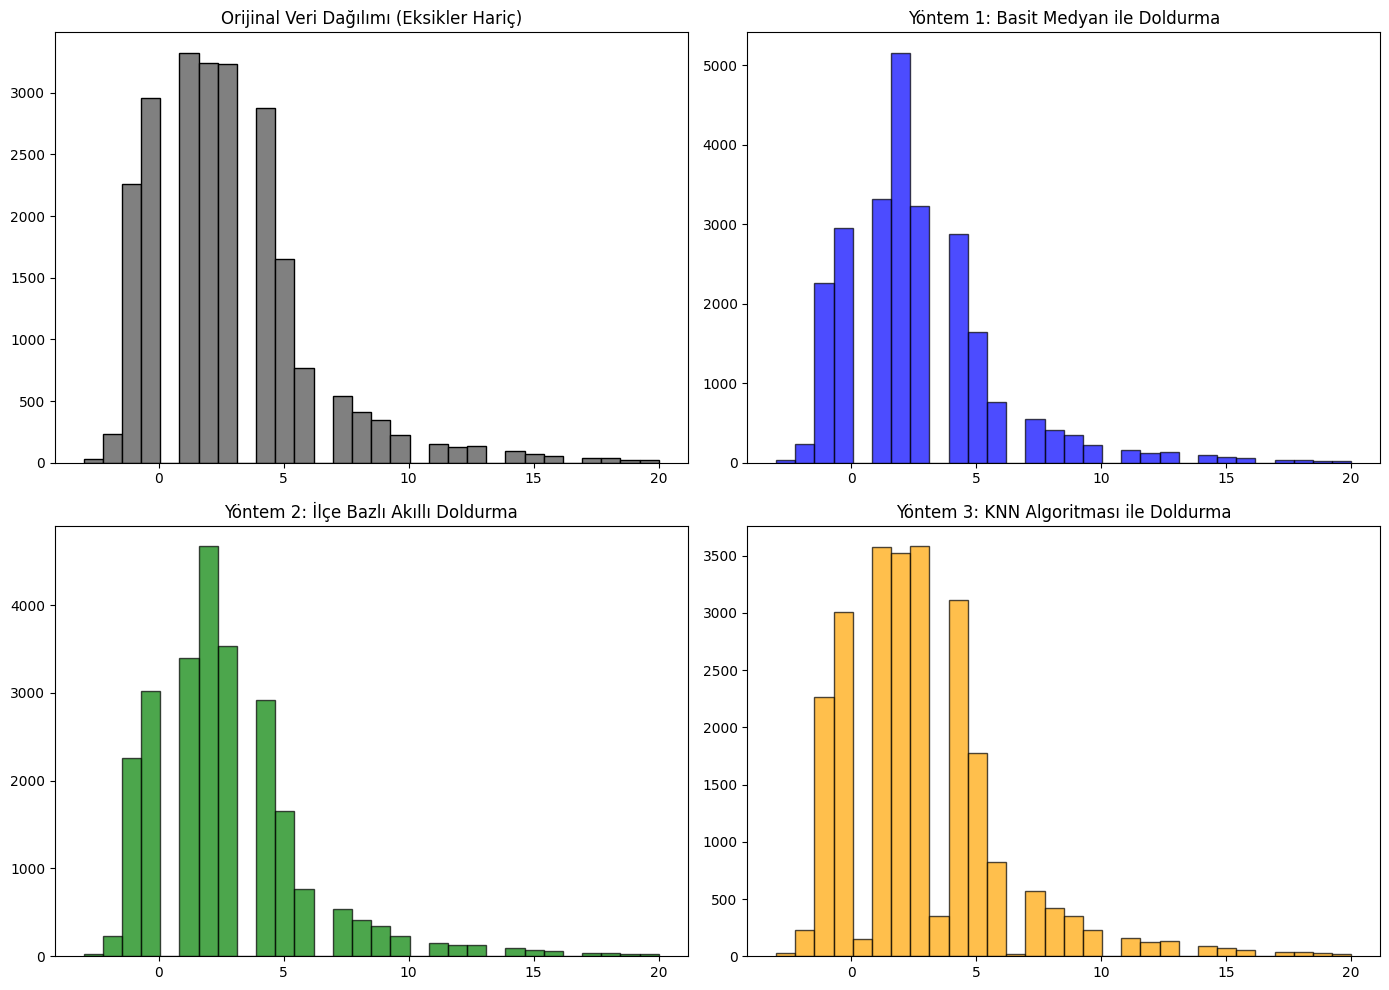

In [5]:
import matplotlib.pyplot as plt

# 4 adet grafik çizeceğimiz için 2x2'lik bir alan oluşturuyoruz
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Orijinal Dağılım (Sadece var olan veriler, gri renk)
axes[0, 0].hist(df_temiz['floor'].dropna(), bins=30, color='gray', edgecolor='black')
axes[0, 0].set_title('Orijinal Veri Dağılımı (Eksikler Hariç)')

# 2. Sabit Medyan ile Doldurulmuş (Mavi renk)
axes[0, 1].hist(df_medyan['floor'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Yöntem 1: Basit Medyan ile Doldurma')

# 3. İlçe Bazlı Grup Medyanı ile Doldurulmuş (Yeşil renk)
axes[1, 0].hist(df_grup['floor'], bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Yöntem 2: İlçe Bazlı Akıllı Doldurma')

# 4. KNN ile Doldurulmuş (Turuncu renk)
axes[1, 1].hist(df_knn['floor'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Yöntem 3: KNN Algoritması ile Doldurma')

plt.tight_layout()
plt.show()

In [11]:
# ==============================================================================
# DOLDURMA YÖNTEMLERİNİN KARŞILAŞTIRILMASI VE SONUÇ:
# ==============================================================================
# Eksik verilerin doldurulması aşamasında basit medyan, grup bazlı medyan ve
# K-Nearest Neighbors (KNN) algoritmaları test edilmiştir.
#
# Görselleştirilmiş dağılım grafiklerinde açıkça görüldüğü üzere;
# basit medyan yöntemi, eksik değerlerin tek bir noktada yığılmasına sebep olarak
# verinin orijinal varyansını bozmuştur.
#
# Buna karşın KNN algoritması, verilerin diğer özellikleriyle olan uzaklık
# ilişkilerini (komşuluk) hesaba kattığı için orijinal veri dağılımını
# en iyi koruyan yöntem olmuştur.
#
# Olasılık projemizin geri kalan hesaplamalarının sapmasız ilerleyebilmesi için
# eksik verilerin KNN yöntemiyle doldurulmasına karar verilmiştir.
# ==============================================================================

# Son olarak, KNN ile doldurulmuş temiz verimizi ekip arkadaşlarıyla
# paylaşmak üzere yeni bir CSV dosyası olarak kaydedelim:


In [13]:
# 1. Eksik kalan TÜM kategorik sütunların listesi (Geri bildirimdeki tüm sütunlar eklendi)
kategorik_eksikler = [
    'building_type', 'fuel_type', 'building_condition',
    'orientation', 'exchange', 'furnished', 'usage_status',
    'credit_eligible', 'deed_status'
]

# 2. Hepsini döngü ile dönüp en çok tekrar eden değer (mod) ile dolduruyoruz
for sutun in kategorik_eksikler:
    # Sütunun veri setimizde olduğundan emin olmak için ufak bir kontrol
    if sutun in df_knn.columns:
        df_knn[sutun] = df_knn[sutun].fillna(df_knn[sutun].mode()[0])

print("Tüm kategorik eksikler başarıyla mod ile dolduruldu!")

# 3. İkinci Eksiğin Çözümü: CSV'yi tüm veriler dolduktan SONRA kaydediyoruz
df_knn.to_csv('istanbul_ev_fiyatlari_temizlenmis_KNN_SON.csv', index=False)

print("Eksiksiz, en güncel CSV dosyası başarıyla kaydedildi!")

Tüm kategorik eksikler başarıyla mod ile dolduruldu!
Eksiksiz, en güncel CSV dosyası başarıyla kaydedildi!
